# IEEE-CIS Fraud Detection: Feature Engineering

We are turning payment records into signals that describe the payment, the information available about it, and its earlier activity. Every feature has a clear purpose, and every learned rule comes from the training period. Our next modeling notebook will test whether these signals help catch fraud at a manageable review volume.

This notebook follows `import_kaggle_data.ipynb` and builds on `BTT-Mastercard-EDA_Done.ipynb` and `../markdowns/EDA_Summary_Notes_1.md`. It runs independently: you do not need variables or saved outputs from either notebook.

four aligned feature tables (training, validation, final holdout, and unlabeled Kaggle test), separate labels and transaction metadata, fitted preprocessing rules, and a feature dictionary. We propose features here; we do **not** claim they improve model performance before validation.

| Step | Decision we can explain to teammates |
|---|---|
| 1–3 | Locate the data, keep every payment when joining identity, and split by time |
| 4–5 | Describe amount, cyclical time, and information availability |
| 6–7 | Simplify email/device strings and learn frequency/amount context on training only |
| 8 | Describe strictly earlier activity for approximate accounts |
| 9–10 | Apply a consistent model schema and check that the features behave correctly |
| 11–12 | Inspect training examples and save a reproducible modeling handoff |

Run all cells in order using the project’s `.venv` kernel with `requirements.txt` installed. The CSVs are large; several GB of available RAM and disk space are needed. Outputs go under the Git-ignored `outputs/` directory.

## 1. Make the run portable and reproducible

locate the repository whether Jupyter starts in the project root or `notebooks/`, and put all run settings in one place. To use files downloaded elsewhere by the import notebook, set `DATA_DIR_OVERRIDE` to that notebook’s printed download path.

teammates should reproduce the same features without logging into Kaggle again or relying on another notebook’s memory.

Our data preparation is a standalone workflow. Everyone uses the same settings, and we save those settings beside the features.

In [1]:
from pathlib import Path
import gc
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "requirements.txt").exists() and (p / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter in the project root or notebooks/ folder.")

DATA_DIR_OVERRIDE = None  # Example: Path("/your/kaggle/download/path")
DATA_DIR = Path(DATA_DIR_OVERRIDE) if DATA_DIR_OVERRIDE else PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "feature_engineering"
TRAIN_SHARE = 0.80
VALIDATION_SHARE = 0.10  # Latest 10% is the final labeled holdout.
READ_NROWS = None  # Set, e.g., 20_000 for a smoke run; restore None for the real run.
SAVE_ARTIFACTS = True
SECONDS_PER_DAY = 86_400
MISSING_CATEGORY = "__MISSING__"
UNKNOWN_CATEGORY = "__UNSEEN__"

required_files = [
    "train_transaction.csv", "train_identity.csv",
    "test_transaction.csv", "test_identity.csv",
]
missing_files = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(f"Missing {missing_files} in {DATA_DIR}. Run the import notebook first.")
if READ_NROWS is not None:
    OUTPUT_DIR = OUTPUT_DIR / f"smoke_{READ_NROWS}"
    print("SMOKE RUN: partial files; do not use these artifacts to report results.")
print("Data:", DATA_DIR)
print("Outputs:", OUTPUT_DIR)

Matplotlib is building the font cache; this may take a moment.


Data: /Users/kyawthiha/Desktop/Banking-1B-online-payment-fraud-detection-using-high-dimensional-transaction-data/data
Outputs: /Users/kyawthiha/Desktop/Banking-1B-online-payment-fraud-detection-using-high-dimensional-transaction-data/outputs/feature_engineering


## 2. Join identity information without losing payments

load each transaction table, standardize the test identity names (`id-01` → `id_01`), then perform a **left join** on `TransactionID`. A one-to-one join check catches duplicate IDs before they silently multiply rows.

 many payments have no identity record. Dropping them would change our population and remove potentially useful missingness signals. `has_identity_record` records whether the join found a record; it is distinct from whether a particular device field is filled.

Each row remains one payment. We enrich it when identity information exists and keep it when that information is absent.

In [2]:
def load_payments(prefix):
    transactions = pd.read_csv(DATA_DIR / f"{prefix}_transaction.csv", nrows=READ_NROWS)
    identity = pd.read_csv(DATA_DIR / f"{prefix}_identity.csv")
    identity = identity.rename(columns=lambda c: c.replace("-", "_"))
    assert transactions["TransactionID"].is_unique, "Duplicate transaction IDs."
    assert identity["TransactionID"].is_unique, "Duplicate identity IDs."
    assert identity.columns.is_unique, "Identity name normalization created duplicates."
    if READ_NROWS is not None:
        identity = identity[identity["TransactionID"].isin(transactions["TransactionID"])]
    joined = transactions.merge(
        identity, on="TransactionID", how="left", validate="one_to_one", indicator=True,
    )
    joined["has_identity_record"] = joined.pop("_merge").eq("both").astype("int8")
    assert len(joined) == len(transactions), "The join changed the number of payments."
    # Preserve amount precision until amount features have been computed.
    floats = joined.select_dtypes("float64").columns.difference(["TransactionAmt"])
    column_order = joined.columns
    joined = pd.concat(
        [joined.drop(columns=floats), joined[floats].astype("float32")], axis=1,
    ).loc[:, column_order]
    return joined

labeled = load_payments("train")
kaggle_test = load_payments("test")
assert "isFraud" in labeled and "isFraud" not in kaggle_test
assert labeled["isFraud"].isin([0, 1]).all()
assert set(labeled.columns) - {"isFraud"} == set(kaggle_test.columns)
assert set(labeled["TransactionID"]).isdisjoint(kaggle_test["TransactionID"])
for frame in [labeled, kaggle_test]:
    assert frame["TransactionDT"].notna().all()
    assert np.isfinite(frame["TransactionDT"]).all()
    assert frame["TransactionAmt"].notna().all()
    assert np.isfinite(frame["TransactionAmt"]).all()
    assert frame["TransactionAmt"].ge(0).all(), "Review negative amounts before using log1p."

raw_feature_columns = [c for c in labeled.columns if c not in {
    "TransactionID", "TransactionDT", "isFraud", "has_identity_record",
}]
identity_columns = [c for c in raw_feature_columns if c.startswith("id_")]
identity_columns += [c for c in ["DeviceType", "DeviceInfo"] if c in raw_feature_columns]
print(f"Labeled payments: {len(labeled):,}; unlabeled Kaggle payments: {len(kaggle_test):,}")
print(f"Raw candidate inputs: {len(raw_feature_columns)}")

Labeled payments: 590,540; unlabeled Kaggle payments: 506,691
Raw candidate inputs: 431


## 3. Reserve the future before learning preparation rules

sort labeled payments by `TransactionDT`, use approximately the earliest 80% for training, the next 10% for validation, and the last 10% as a final holdout. A boundary moves to the start of a timestamp so simultaneous payments cannot straddle two periods.

the EDA used the earliest 80% as training. We retain that period and divide its later 20% into development validation and final evaluation. This differs from the EDA’s single 80/20 split, so future model comparisons must all use this notebook’s saved split. The holdout is reserved now, before tuning.

`TransactionDT` measures elapsed seconds from an unknown reference. We use it to order payments and create cycles, not to invent calendar dates. The Kaggle test has no labels and cannot measure accuracy or PR-AUC. A chronological split also does not reproduce the month-long gap noted in the EDA; a gap-based validation experiment remains a later robustness check.

We train on earlier payments and judge decisions on later payments. Validation guides our choices; the final holdout is evaluated once after those choices are fixed.

In [3]:
labeled = labeled.sort_values(["TransactionDT", "TransactionID"]).reset_index(drop=True)
kaggle_test = kaggle_test.sort_values(["TransactionDT", "TransactionID"]).reset_index(drop=True)
times = labeled["TransactionDT"].to_numpy()

def boundary_at_timestamp(fraction):
    nominal_row = min(int(len(times) * fraction), len(times) - 1)
    return int(np.searchsorted(times, times[nominal_row], side="left"))

train_end = boundary_at_timestamp(TRAIN_SHARE)
validation_end = boundary_at_timestamp(TRAIN_SHARE + VALIDATION_SHARE)
assert 0 < train_end < validation_end < len(labeled), "Not enough timestamps for three periods."
raw_splits = {
    "train": labeled.iloc[:train_end].copy(),
    "validation": labeled.iloc[train_end:validation_end].copy(),
    "holdout": labeled.iloc[validation_end:].copy(),
    "kaggle_test": kaggle_test,
}
assert raw_splits["train"]["TransactionDT"].max() < raw_splits["validation"]["TransactionDT"].min()
assert raw_splits["validation"]["TransactionDT"].max() < raw_splits["holdout"]["TransactionDT"].min()
assert raw_splits["holdout"]["TransactionDT"].max() < raw_splits["kaggle_test"]["TransactionDT"].min()

split_summary = pd.DataFrame([
    {"split": name, "rows": len(frame),
     "first_elapsed_day": frame["TransactionDT"].min() / SECONDS_PER_DAY,
     "last_elapsed_day": frame["TransactionDT"].max() / SECONDS_PER_DAY}
    for name, frame in raw_splits.items()
]).set_index("split")
display(split_summary.round(2))
print(f"Training fraud share: {raw_splits['train']['isFraud'].mean():.2%}")
# Holdout labels are separated for the modeling handoff; never used by feature functions.
labels = {
    name: frame.set_index("TransactionID")["isFraud"].astype("int8")
    for name, frame in raw_splits.items() if "isFraud" in frame
}
metadata = {
    name: frame.set_index("TransactionID")[["TransactionDT"]].copy()
    for name, frame in raw_splits.items()
}
for name in raw_splits:
    raw_splits[name] = raw_splits[name].drop(columns="isFraud", errors="ignore")
del labeled, kaggle_test, times
gc.collect()

,rows,first_elapsed_day,last_elapsed_day
split,,,
train,472432,1.00,141.12
validation,59054,141.12,161.93
holdout,59054,161.93,183.00
kaggle_test,506691,213.00,396.00


Training fraud share: 3.51%


0

## 4. Describe the amount and recurring time patterns

retain the raw amount, add `log(1 + amount)`, its fractional-unit component, and a flag for sub-cent precision. For time, add elapsed-hour and seven-day-cycle positions and their sine/cosine encodings.

logarithms compress very large payments. Fractional amounts can describe payment formatting; they do not prove a payment was international. Sine and cosine place the end and start of a cycle close together: hour 23 is close to hour 0.

The reference time and timezone are unknown. `relative_hour` is an elapsed-time cycle position, not a verified local hour, and `relative_weekday` is 0–6 without Monday/Sunday labels. We exclude raw time and day from model inputs because later data falls beyond the training date range.

We describe both the payment’s size and recurring timing patterns. We preserve the raw amount while offering alternate representations that different models can use.

In [4]:
feature_groups = {}

def amount_time_features(frame):
    amount = frame["TransactionAmt"].astype("float64")
    time = frame["TransactionDT"]
    hour = (time // 3_600 % 24).astype("int8")
    weekday = (time // SECONDS_PER_DAY % 7).astype("int8")
    return pd.DataFrame({
        "amount_log1p": np.log1p(amount).astype("float32"),
        "amount_fractional_unit": (amount - np.floor(amount)).astype("float32"),
        "amount_has_subcent_precision": (~np.isclose(
            amount * 100, np.round(amount * 100), rtol=0, atol=1e-6,
        )).astype("int8"),
        "relative_hour": hour,
        "hour_sin": np.sin(2 * np.pi * hour / 24).astype("float32"),
        "hour_cos": np.cos(2 * np.pi * hour / 24).astype("float32"),
        "relative_weekday": weekday,
        "weekday_sin": np.sin(2 * np.pi * weekday / 7).astype("float32"),
        "weekday_cos": np.cos(2 * np.pi * weekday / 7).astype("float32"),
    }, index=frame.index)

features = {
    name: frame[raw_feature_columns + ["has_identity_record"]].copy()
    for name, frame in raw_splits.items()
}
for name, frame in raw_splits.items():
    additions = amount_time_features(frame)
    features[name] = pd.concat([features[name], additions], axis=1)
feature_groups["amount_time"] = additions.columns.tolist()

## 5. Preserve what is missing before filling or encoding anything

count missing values across the original inputs and within identity, card/address, and anonymous V fields. We also create explicit missing flags for address, emails, device information, and `D1`.

EDA found that information availability can be predictive. A missing field can reflect a different collection process or product, so it should not automatically be replaced by zero or interpreted as suspicious. Counts use a fixed raw-column list, so they do not change as we add engineered features.

We retain sparse anonymous columns rather than dropping them solely for being mostly empty. This first version keeps all V columns; training-only correlation reduction and missingness clustering are later experiments.

The absence of information is part of the payment record. We let the model learn whether that absence matters in combination with the product and other inputs.

In [5]:
v_columns = [c for c in raw_feature_columns if re.fullmatch(r"V\d+", c)]
card_address_columns = [c for c in raw_feature_columns if c.startswith("card") or c.startswith("addr")]
missing_flag_sources = [
    "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceInfo", "D1",
]

def missingness_features(frame):
    data = {
        "raw_missing_count": frame[raw_feature_columns].isna().sum(axis=1).astype("int16"),
        "identity_missing_count": frame[identity_columns].isna().sum(axis=1).astype("int16"),
        "card_address_missing_count": frame[card_address_columns].isna().sum(axis=1).astype("int16"),
        "v_missing_count": frame[v_columns].isna().sum(axis=1).astype("int16"),
    }
    data.update({f"{c}_missing": frame[c].isna().astype("int8") for c in missing_flag_sources})
    return pd.DataFrame(data, index=frame.index)

for name, frame in raw_splits.items():
    additions = missingness_features(frame)
    features[name] = pd.concat([features[name], additions], axis=1)
feature_groups["missingness"] = ["has_identity_record"] + additions.columns.tolist()

## 6. Turn email and device strings into understandable groups

lowercase and trim email domains, extract the first domain token as a provider proxy, and describe whether purchaser/recipient domains match or are missing. We map `DeviceInfo` to a small set of families using explicit keyword rules.

raw device strings contain many versions and rare spellings. Broader groups can generalize across versions and be easier to explain. The first email token is a heuristic, not a verified company identity; email matching compares domains, not full email addresses. Device rules also make mistakes, so their value needs validation.

We keep normalized full email domains as candidates, replace raw `DeviceInfo` with `device_family`, and treat unfamiliar device strings as `other`.

We give the model stable, understandable groups while acknowledging that our grouping rules are approximations.

In [6]:
DEVICE_RULES = [
    ("windows", "windows"), ("macos", "macos"), ("mac os", "macos"),
    ("ios", "ios"), ("iphone", "ios"), ("ipad", "ios"),
    ("sm-", "samsung"), ("samsung", "samsung"), ("gt-", "samsung"),
    ("huawei", "huawei"), ("moto", "motorola"), ("pixel", "google"),
    ("nexus", "google"), ("lg-", "lg"), ("lenovo", "lenovo"),
    ("zte", "zte"), ("linux", "linux"), ("android", "android_other"),
    ("build/", "android_other"),
]

def normalized_domain(series):
    return series.astype("string").str.strip().str.lower().replace("", pd.NA)

def device_family(value):
    if pd.isna(value):
        return MISSING_CATEGORY
    text = str(value).strip().lower()
    if not text:
        return MISSING_CATEGORY
    return next((family for token, family in DEVICE_RULES if token in text), "other")

def email_device_features(frame):
    purchaser = normalized_domain(frame["P_emaildomain"])
    recipient = normalized_domain(frame["R_emaildomain"])
    relationship = pd.Series("different_domains", index=frame.index, dtype="string")
    relationship.loc[purchaser.eq(recipient).fillna(False)] = "same_domain"
    relationship.loc[purchaser.isna()] = "purchaser_missing"
    relationship.loc[recipient.isna()] = "recipient_missing"
    relationship.loc[purchaser.isna() & recipient.isna()] = "both_missing"
    return pd.DataFrame({
        "P_emaildomain": purchaser,
        "R_emaildomain": recipient,
        "P_provider": purchaser.str.split(".").str[0],
        "R_provider": recipient.str.split(".").str[0],
        "email_domain_relationship": relationship,
        "device_family": frame["DeviceInfo"].map(device_family),
    }, index=frame.index)

for name, frame in raw_splits.items():
    additions = email_device_features(frame)
    features[name] = features[name].drop(columns=["P_emaildomain", "R_emaildomain", "DeviceInfo"])
    features[name] = pd.concat([features[name], additions], axis=1)
feature_groups["email_device"] = ["P_provider", "R_provider", "email_domain_relationship", "device_family"]

## 7. Learn frequency and amount context from training only

fit category-frequency tables for card, address, email/provider, and device groups. Add an amount-frequency feature using amounts rounded to cents, and compare each amount with the training median for its product.

this describes whether a category or rounded amount was common in the training population and whether a payment is large relative to its product. An unseen value receives frequency zero. Missing values receive their own training frequency. An unseen product uses the overall training median; denominators are floored at 1 to keep ratios finite.

These are **offline fitted reference statistics**, not claims about how many payments preceded a transaction. Training rows share the training-period reference, as they would share a fitted scaler. Validation, holdout, and Kaggle data never update those references. We use **all training amounts**, not just legitimate payments, so no fraud label enters the features.

We establish a reference from the training population and apply it unchanged to future payments. These features describe rarity and size, not whether a category is inherently fraudulent.

In [7]:
FREQUENCY_SOURCES = [
    "card1", "card2", "addr1", "P_emaildomain", "R_emaildomain",
    "P_provider", "device_family",
]

def reference_key(series):
    return series.astype("string").fillna(MISSING_CATEGORY)

def rounded_amount_key(series):
    return np.rint(series.astype("float64") * 100).astype("int64").astype("string")

training_features = features["train"]
frequency_maps = {
    c: reference_key(training_features[c]).value_counts(normalize=True).to_dict()
    for c in FREQUENCY_SOURCES
}
amount_frequency_map = rounded_amount_key(training_features["TransactionAmt"]).value_counts(normalize=True).to_dict()
product_medians = training_features.groupby("ProductCD", observed=True)["TransactionAmt"].median().to_dict()
global_amount_median = float(training_features["TransactionAmt"].median())

def reference_features(frame):
    data = {
        f"{c}_train_frequency": reference_key(frame[c]).map(mapping).fillna(0).astype("float32")
        for c, mapping in frequency_maps.items()
    }
    data["amount_train_frequency"] = rounded_amount_key(frame["TransactionAmt"]).map(
        amount_frequency_map,
    ).fillna(0).astype("float32")
    denominator = frame["ProductCD"].map(product_medians).fillna(global_amount_median).clip(lower=1)
    data["amount_to_product_median"] = (frame["TransactionAmt"] / denominator).astype("float32")
    return pd.DataFrame(data, index=frame.index)

for name in features:
    additions = reference_features(features[name])
    features[name] = pd.concat([features[name], additions], axis=1)
feature_groups["training_reference"] = additions.columns.tolist()
del training_features

## 8. Build account activity using strictly earlier payments
define an approximate account key using `card1`, `addr1`, and `floor(TransactionDT / 86400) − D1`, following the EDA hypothesis. If any component is missing, we leave the key missing rather than grouping unrelated incomplete records together. The key itself is metadata, never a model input.

For complete keys, we add the number of earlier payments, their mean amount, the current amount relative to that mean, and seconds since the previous timestamp. Payments at the **same timestamp are processed together**: none can use another simultaneous payment. The function aggregates each account/timestamp, then shifts cumulative summaries before joining them back.

a full-data `groupby(...).mean()` or count would tell an early payment about later activity. Our history features only use `TransactionDT` values strictly smaller than the current one and never use labels. A zero prior count means no observed history; mean/ratio/gap remain missing in that case.

we simulate sequential scoring. As time passes, previous unlabeled validation/holdout/Kaggle payments may enter the activity history, without updating the trained model or reference maps. All four periods are combined only as a narrow event log; chronological ordering prevents future rows from changing earlier histories. A batch system unable to update activity state would require a different evaluation. This workflow is not a persistent production state store.

`D1` is masked and the account key is uncertain. Shared card/address values can join different people, and missing addresses cannot be linked by this rule. We must compare results with and without these features and inspect seen versus new keys.

We ask what activity was already observable when each payment arrived. We avoid fraud history because confirmed fraud labels may arrive much later.

In [8]:
def approximate_account_key(frame):
    components = pd.DataFrame({
        "card": frame["card1"],
        "address": frame["addr1"],
        "start_day_proxy": frame["TransactionDT"] // SECONDS_PER_DAY - frame["D1"],
    }, index=frame.index)
    complete = components.notna().all(axis=1) & np.isfinite(components).all(axis=1)
    key = pd.Series(pd.NA, index=frame.index, dtype="string")
    parts = components.loc[complete].astype("string")
    key.loc[complete] = parts["card"] + "|" + parts["address"] + "|" + parts["start_day_proxy"]
    return key

HISTORY_COLUMNS = [
    "account_key_missing", "account_has_prior_history", "account_prior_count",
    "account_prior_mean_amount", "amount_to_prior_account_mean", "account_seconds_since_previous",
]

def strict_past_activity(events):
    # Input is a narrow, unlabeled event log indexed by unique TransactionID.
    assert events.index.is_unique
    eligible = events[events["account_key"].notna()]
    by_time = eligible.groupby(["account_key", "TransactionDT"], sort=True).agg(
        event_count=("TransactionAmt", "size"),
        amount_count=("TransactionAmt", "count"),
        amount_sum=("TransactionAmt", "sum"),
    ).reset_index()
    groups = by_time.groupby("account_key", sort=False)
    by_time["account_prior_count"] = groups["event_count"].cumsum() - by_time["event_count"]
    prior_amount_count = groups["amount_count"].cumsum() - by_time["amount_count"]
    prior_amount_sum = groups["amount_sum"].cumsum() - by_time["amount_sum"]
    by_time["account_prior_mean_amount"] = prior_amount_sum / prior_amount_count.replace(0, np.nan)
    by_time["account_seconds_since_previous"] = by_time["TransactionDT"] - groups["TransactionDT"].shift(1)
    lookup = by_time.set_index(["account_key", "TransactionDT"])[[
        "account_prior_count", "account_prior_mean_amount", "account_seconds_since_previous",
    ]]
    result = events[["account_key", "TransactionDT", "TransactionAmt"]].join(
        lookup, on=["account_key", "TransactionDT"], validate="many_to_one",
    )
    result["account_key_missing"] = result["account_key"].isna().astype("int8")
    result["account_prior_count"] = result["account_prior_count"].fillna(0).astype("int32")
    result["account_has_prior_history"] = result["account_prior_count"].gt(0).astype("int8")
    prior_mean = result["account_prior_mean_amount"]
    result["amount_to_prior_account_mean"] = result["TransactionAmt"] / prior_mean.clip(lower=1)
    return result[HISTORY_COLUMNS]

event_parts = []
for name, frame in raw_splits.items():
    key = approximate_account_key(frame)
    metadata[name]["approximate_account_key"] = key.to_numpy()
    event = frame.set_index("TransactionID")[["TransactionDT", "TransactionAmt"]].copy()
    event["account_key"] = key.to_numpy()
    event_parts.append(event)
events = pd.concat(event_parts)
history = strict_past_activity(events)
train_keys = set(metadata["train"]["approximate_account_key"].dropna())
for name, frame in raw_splits.items():
    additions = history.loc[frame["TransactionID"]].set_axis(frame.index)
    features[name] = pd.concat([features[name], additions], axis=1)
    metadata[name]["account_key_seen_in_training"] = metadata[name]["approximate_account_key"].isin(train_keys)
feature_groups["past_activity"] = HISTORY_COLUMNS
history_state_at_end = events.dropna(subset=["account_key"]).groupby("account_key").agg(
    prior_count=("TransactionAmt", "size"),
    prior_amount_count=("TransactionAmt", "count"),
    prior_amount_sum=("TransactionAmt", "sum"),
    last_transaction_dt=("TransactionDT", "max"),
)
# This state is after all four periods; never seed an earlier backtest with it.
del event_parts, events, history, key, event, additions, train_keys
gc.collect()

38

## 9. Apply one model schema with explicit missing and unseen categories

identify categorical columns, including numerically stored card/address codes and `id_12`–`id_38`. Learn their allowed values from training only, then apply the same category order to every split. Missing values and unseen values get separate categories. Numerical columns are stored as `float32`, with missing values preserved.

a card code such as 1234 is a category, not a number where larger means riskier. A validation-only category must not change the training vocabulary. These outputs suit a tree model that supports pandas categoricals and numerical missing values, such as LightGBM. They are **not** ready for an MLP or logistic regression: those models need a training-fitted imputer, categorical encoder, and scaler in the next notebook. Do not pass category integer codes as continuous values.

We do not impute, scale, oversample, or select features using later data. Resampling, if tried later, belongs inside training only. We retain rare/sparse features for comparison and let validation establish whether they help.

The meaning and ordering of every input stays the same from training to prediction, even when a new category appears.

In [9]:
train_features = features["train"]
explicit_categorical = {
    "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6", "addr1", "addr2",
    "relative_hour", "relative_weekday",
}
explicit_categorical |= {f"id_{i:02d}" for i in range(12, 39)}
categorical_columns = [
    c for c in train_features.columns
    if c in explicit_categorical or not pd.api.types.is_numeric_dtype(train_features[c])
]
numeric_columns = [c for c in train_features.columns if c not in categorical_columns]
category_vocabularies = {}
for column in categorical_columns:
    values = reference_key(train_features[column])
    observed = sorted(set(values) - {MISSING_CATEGORY, UNKNOWN_CATEGORY})
    vocabulary = [MISSING_CATEGORY, UNKNOWN_CATEGORY] + observed
    category_vocabularies[column] = vocabulary
    dtype = pd.CategoricalDtype(categories=vocabulary, ordered=False)
    for name in features:
        values = reference_key(features[name][column])
        values = values.where(values.isin(vocabulary), UNKNOWN_CATEGORY)
        features[name][column] = values.astype(dtype)

for name, frame in raw_splits.items():
    numerical = features[name][numeric_columns].replace(
        [np.inf, -np.inf], np.nan,
    ).astype("float32")
    features[name] = pd.concat([features[name][categorical_columns], numerical], axis=1)
    features[name].index = pd.Index(frame["TransactionID"], name="TransactionID")
    features[name] = features[name].loc[:, features["train"].columns]

engineered_columns = {c for columns in feature_groups.values() for c in columns}
feature_groups["raw_retained"] = [c for c in features["train"].columns if c not in engineered_columns]
feature_sets = {
    "raw_baseline": feature_groups["raw_retained"],
    "engineered_without_history": [c for c in features["train"] if c not in HISTORY_COLUMNS],
    "engineered_with_history": features["train"].columns.tolist(),
}
# Baseline uses the same split/schema, with raw DeviceInfo omitted for a controlled comparison.
del train_features, raw_splits, values, frame, numerical
gc.collect()

0

## 10. Check alignment and prove the history rules on a tiny example

check IDs, labels, feature order, types, missing handling, and the absence of target/time/key inputs. Then verify a hand-calculable activity sequence: two simultaneous payments see the same past, missing keys do not share history, and appending a future payment does not rewrite earlier features. Finally, verify that novel categories and amounts receive frequency zero without modifying fitted maps.

a plausible-looking feature table can still be wrong. These checks test the behaviors that protect our experiment from leakage and misaligned labels.

Before modeling, we check both the table structure and the time logic. We can demonstrate exactly what an earlier transaction is allowed to know.

In [10]:
expected_columns = features["train"].columns.tolist()
forbidden_inputs = {"isFraud", "TransactionID", "TransactionDT", "day", "uid", "account_key", "approximate_account_key", "DeviceInfo"}
assert forbidden_inputs.isdisjoint(expected_columns)
for name, frame in features.items():
    assert frame.index.is_unique and frame.columns.is_unique
    assert frame.columns.tolist() == expected_columns
    assert frame.index.equals(metadata[name].index)
    if name in labels:
        assert frame.index.equals(labels[name].index)
    assert not np.isinf(frame[numeric_columns].to_numpy()).any()
    assert frame[categorical_columns].notna().all().all()
    for column in categorical_columns:
        assert frame[column].cat.categories.tolist() == category_vocabularies[column]
    assert frame["account_prior_count"].ge(0).all()
    assert frame["account_seconds_since_previous"].dropna().gt(0).all()
    no_history = frame["account_prior_count"].eq(0)
    assert frame.loc[no_history, "account_prior_mean_amount"].isna().all()
    assert frame.loc[no_history, "account_seconds_since_previous"].isna().all()
    assert frame.loc[frame["account_key_missing"].eq(1), "account_prior_count"].eq(0).all()

# At t=20 both A payments see only A's amount=10 payment at t=10.
toy = pd.DataFrame({
    "TransactionDT": [10, 20, 20, 30, 40, 50],
    "TransactionAmt": [10., 20., 40., 80., 7., 9.],
    "account_key": ["A", "A", "A", "A", pd.NA, pd.NA],
}, index=pd.Index([1, 2, 3, 4, 5, 6], name="TransactionID"))
toy_history = strict_past_activity(toy)
assert toy_history["account_prior_count"].tolist() == [0, 1, 1, 3, 0, 0]
assert toy_history.loc[[2, 3], "account_prior_mean_amount"].eq(10).all()
assert np.isclose(toy_history.loc[4, "account_prior_mean_amount"], 70 / 3)
assert toy_history.loc[4, "account_seconds_since_previous"] == 10
future = pd.DataFrame({"TransactionDT": [60], "TransactionAmt": [999.], "account_key": ["A"]}, index=[7])
pd.testing.assert_frame_equal(toy_history, strict_past_activity(pd.concat([toy, future])).loc[toy.index])
pd.testing.assert_frame_equal(toy_history, strict_past_activity(toy.sample(frac=1, random_state=42)).loc[toy.index])
missing_components = pd.DataFrame({"card1": [1., 1.], "addr1": [np.nan, 2.], "D1": [0., np.nan], "TransactionDT": [10, 20]})
assert approximate_account_key(missing_components).isna().all()

probe = features["train"].iloc[:1].astype("object").copy()
for column in FREQUENCY_SOURCES:
    probe[column] = "__new_value_for_check__"
probe["ProductCD"] = "__new_product_for_check__"
new_amount_key = max(int(k) for k in amount_frequency_map) + 100
probe["TransactionAmt"] = new_amount_key / 100
probe_features = reference_features(probe)
assert probe_features.filter(like="frequency").eq(0).all().all()
assert np.isclose(probe_features["amount_to_product_median"].iloc[0], (new_amount_key / 100) / max(global_amount_median, 1))
print(f"Checks passed: {len(expected_columns)} aligned inputs; strict past and unseen-value behavior verified.")

Checks passed: 469 aligned inputs; strict past and unseen-value behavior verified.


## 11. What the features look like

summarize feature families, show a few training examples, and plot raw versus log amounts and information availability. All exploratory views use training only; final holdout labels remain unused.

we need to explain the features in concrete terms and spot unexpected values before the next modeling stage. These plots describe inputs, not model quality or causal evidence.

Here are real examples of the signals we built. The next question is whether they improve future-period fraud detection, which we will test using the saved feature sets.

type,categorical,numeric
family,,
amount_time,2,7
email_device,4,0
missingness,0,11
past_activity,0,6
raw_retained,48,382
training_reference,0,9


,TransactionAmt,amount_log1p,amount_to_product_median,relative_hour,has_identity_record,raw_missing_count,P_provider,device_family,account_key_missing,account_prior_count,account_prior_mean_amount
TransactionID,,,,,,,,,,,
2987000,68.5,4.241327,0.867418,0,0.0,234.0,__MISSING__,__MISSING__,0.0,0.0,NaN
2987001,29.0,3.401197,0.367228,0,0.0,230.0,gmail,__MISSING__,0.0,0.0,NaN
2987002,59.0,4.094345,0.747119,0,0.0,211.0,outlook,__MISSING__,0.0,0.0,NaN
2987003,50.0,3.931826,0.633152,0,0.0,227.0,yahoo,__MISSING__,0.0,0.0,NaN
2987004,50.0,3.931826,1.000000,0,1.0,137.0,gmail,samsung,0.0,0.0,NaN
2987005,49.0,3.912023,0.620489,0,0.0,214.0,gmail,__MISSING__,0.0,0.0,NaN
2987006,159.0,5.075174,2.013423,0,0.0,211.0,yahoo,__MISSING__,0.0,0.0,NaN
2987007,422.5,6.048553,5.350133,0,0.0,230.0,mail,__MISSING__,0.0,0.0,NaN


,dtype,numeric_missing_share,distinct_training_values
id_08,float32,0.990981,94
id_07,float32,0.990981,83
D7,float32,0.936617,569
dist2,float32,0.932054,1665
D13,float32,0.896339,528
D14,float32,0.894512,764
D12,float32,0.888443,601
id_03,float32,0.885507,25
id_04,float32,0.885507,16
D6,float32,0.876209,782


Categorical missingness is represented explicitly, so it does not appear as NaN above.


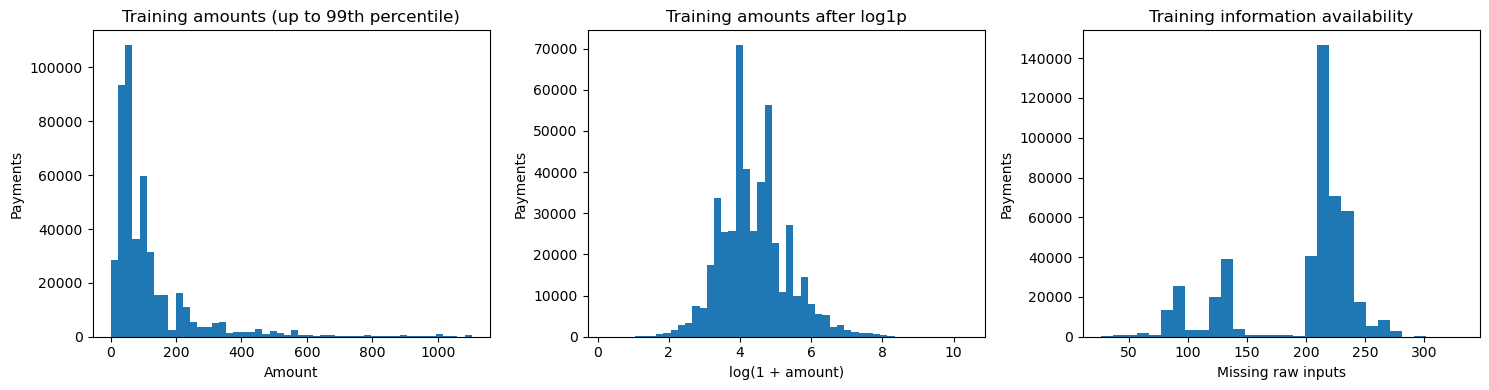

In [11]:
feature_dictionary = pd.DataFrame([
    {"feature": column, "family": family,
     "type": "categorical" if column in categorical_columns else "numeric",
     "missing_policy": "explicit missing/unseen categories" if column in categorical_columns else "preserve NaN",
     "source_rule": {
         "raw_retained": "Original input (email domains normalized); training category vocabulary where needed",
         "amount_time": "Current payment only; category vocabulary fitted on training where needed",
         "missingness": "Current raw record only",
         "email_device": "Fixed string rules; category vocabulary fitted on training",
         "training_reference": "Frozen training-only frequency or amount reference",
         "past_activity": "Unlabeled payments at strictly smaller TransactionDT only",
     }[family]}
    for family, columns in feature_groups.items() for column in columns
])
display(feature_dictionary.groupby(["family", "type"]).size().unstack(fill_value=0))
example_columns = [
    "TransactionAmt", "amount_log1p", "amount_to_product_median", "relative_hour",
    "has_identity_record", "raw_missing_count", "P_provider", "device_family",
    "account_key_missing", "account_prior_count", "account_prior_mean_amount",
]
display(features["train"][example_columns].head(8))
train_quality = pd.DataFrame({
    "dtype": features["train"].dtypes.astype(str),
    "numeric_missing_share": features["train"].isna().mean(),
    "distinct_training_values": features["train"].nunique(dropna=False),
})
display(train_quality.sort_values("numeric_missing_share", ascending=False).head(12))
print("Categorical missingness is represented explicitly, so it does not appear as NaN above.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train = features["train"]
amount_cap = train["TransactionAmt"].quantile(0.99)
axes[0].hist(train.loc[train["TransactionAmt"] <= amount_cap, "TransactionAmt"], bins=50)
axes[0].set(title="Training amounts (up to 99th percentile)", xlabel="Amount", ylabel="Payments")
axes[1].hist(train["amount_log1p"], bins=50)
axes[1].set(title="Training amounts after log1p", xlabel="log(1 + amount)", ylabel="Payments")
axes[2].hist(train["raw_missing_count"], bins=30)
axes[2].set(title="Training information availability", xlabel="Missing raw inputs", ylabel="Payments")
plt.tight_layout()
plt.show()
del train

## 12. Save the modeling handoff and the decisions behind it

save `X_<split>.parquet` with `TransactionID` as its index, labeled `y_<split>.parquet` separately, and `metadata_<split>.parquet` with time and account information for evaluation slices. Save reference maps, category vocabularies, feature families, named comparison sets, split boundaries, versions, and the feature dictionary.

the next notebook can load identical features and labels without repeating this work. Keep artifacts local under `outputs/`; they contain transaction data. JSON stores fitted rules in a readable format, while Parquet preserves categorical types and numeric missing values. The saved end-of-stream history snapshot is for continuation after the Kaggle period, never for replaying earlier validation/holdout rows. The notebook functions plus saved settings define how to rebuild the features; there is no deployable inference pipeline yet.

We hand over aligned inputs, labels, and a record of every preparation decision. Our model comparison can now change one feature family at a time while keeping the data split fixed.

In [12]:
run_manifest = {
    "dataset": "IEEE-CIS Fraud Detection",
    "full_data_run": READ_NROWS is None,
    "read_nrows": READ_NROWS,
    "train_share_requested": TRAIN_SHARE,
    "validation_share_requested": VALIDATION_SHARE,
    "split_summary": split_summary.reset_index().to_dict(orient="records"),
    "feature_columns": expected_columns,
    "categorical_columns": categorical_columns,
    "numeric_columns": numeric_columns,
    "feature_groups": feature_groups,
    "feature_sets": feature_sets,
    "raw_missingness_columns": raw_feature_columns,
    "identity_columns": identity_columns,
    "dropped_model_inputs": ["TransactionID", "TransactionDT", "DeviceInfo", "approximate_account_key"],
    "history_policy": "Strictly earlier timestamps; sequential unlabeled updates across all periods; no fraud labels",
    "account_key_rule": "card1|addr1|floor(TransactionDT/86400)-D1; missing if any component missing",
    "history_state_position": "After final Kaggle timestamp; do not use for an earlier backtest",
    "reference_policy": "All reference statistics and category vocabularies fitted on earliest training period only",
    "missing_category": MISSING_CATEGORY,
    "unknown_category": UNKNOWN_CATEGORY,
    "device_rules": DEVICE_RULES,
    "versions": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__},
}
preprocessing_rules = {
    "frequency_maps": frequency_maps,
    "amount_frequency_map": amount_frequency_map,
    "amount_frequency_rule": "numpy.rint(amount * 100), cast to int64 string",
    "product_medians": {str(k): float(v) for k, v in product_medians.items()},
    "global_amount_median": global_amount_median,
    "amount_ratio_denominator_floor": 1,
    "category_vocabularies": category_vocabularies,
}

if SAVE_ARTIFACTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, frame in features.items():
        frame.to_parquet(OUTPUT_DIR / f"X_{name}.parquet")
        metadata[name].to_parquet(OUTPUT_DIR / f"metadata_{name}.parquet")
        if name in labels:
            labels[name].to_frame().to_parquet(OUTPUT_DIR / f"y_{name}.parquet")
    history_state_at_end.to_parquet(OUTPUT_DIR / "history_state_after_kaggle.parquet")
    feature_dictionary.to_csv(OUTPUT_DIR / "feature_dictionary.csv", index=False)
    for filename, payload in [("run_manifest.json", run_manifest), ("preprocessing_rules.json", preprocessing_rules)]:
        (OUTPUT_DIR / filename).write_text(json.dumps(payload, indent=2, allow_nan=False) + "\n")
    # Verify that the persisted schema and values survive a real round trip.
    restored = pd.read_parquet(OUTPUT_DIR / "X_train.parquet")
    pd.testing.assert_frame_equal(features["train"], restored)
    del restored
    print("Saved artifacts and verified the training Parquet round trip:", OUTPUT_DIR)
else:
    print("Artifacts not written. Set SAVE_ARTIFACTS=True for the modeling handoff.")

Saved artifacts and verified the training Parquet round trip: /Users/kyawthiha/Desktop/Banking-1B-online-payment-fraud-detection-using-high-dimensional-transaction-data/outputs/feature_engineering


We have a reproducible feature set that describes payment size, recurring timing, information availability, category rarity, and strictly earlier account activity. We keep anonymous inputs because their usefulness should be measured rather than guessed. Preparation rules are fitted on training only, and the account history never sees future payments or fraud outcomes. We now need model experiments to establish which feature families earn their place.

**Next modeling experiments:**

1. Load the saved training/validation tables and labels; check that their `TransactionID` indices match. Use the same split for every comparison.
2. Compare the manifest’s `raw_baseline`, `engineered_without_history`, and `engineered_with_history` sets with a consistent tree-model setup. This baseline omits raw `DeviceInfo`, so record that definition when reporting results.
3. Use PR-AUC (with the scoring definition recorded), precision, recall, false-positive rate, and recall at a fixed review budget. Accuracy alone can hide missed fraud.
4. Inspect validation performance by product, account-key availability, and `account_key_seen_in_training`. These groups test the limits of our approximate account story.
5. If training logistic regression or an MLP, fit imputation, categorical encoding, and scaling on training only. Recompute reference maps, vocabularies, and history preparation inside each training fold if doing cross-validation.
6. Choose features and alert thresholds on validation. Evaluate the final holdout once after choices are fixed; generate Kaggle predictions separately and join them to the sample submission by `TransactionID`, since this notebook sorted rows by time.

improved model performance, reliable real-world customer identity, causal links to fraud, or production readiness. Future experiments can test V-column reduction, richer past-activity windows, gap-based validation, and alternative account keys. Each needs its own validation result before we claim a benefit.

Example loading code for the next notebook:

```python
artifact_dir = PROJECT_ROOT / "outputs" / "feature_engineering"
X_train = pd.read_parquet(artifact_dir / "X_train.parquet")
y_train = pd.read_parquet(artifact_dir / "y_train.parquet")["isFraud"]
X_validation = pd.read_parquet(artifact_dir / "X_validation.parquet")
y_validation = pd.read_parquet(artifact_dir / "y_validation.parquet")["isFraud"]
assert X_train.index.equals(y_train.index)
assert X_validation.index.equals(y_validation.index)
```